Outliers removed: 7 out of 191 entries
IQR bounds: [-15.65, 88.35]
Saved figure to avg_mape_by_features_clean.png


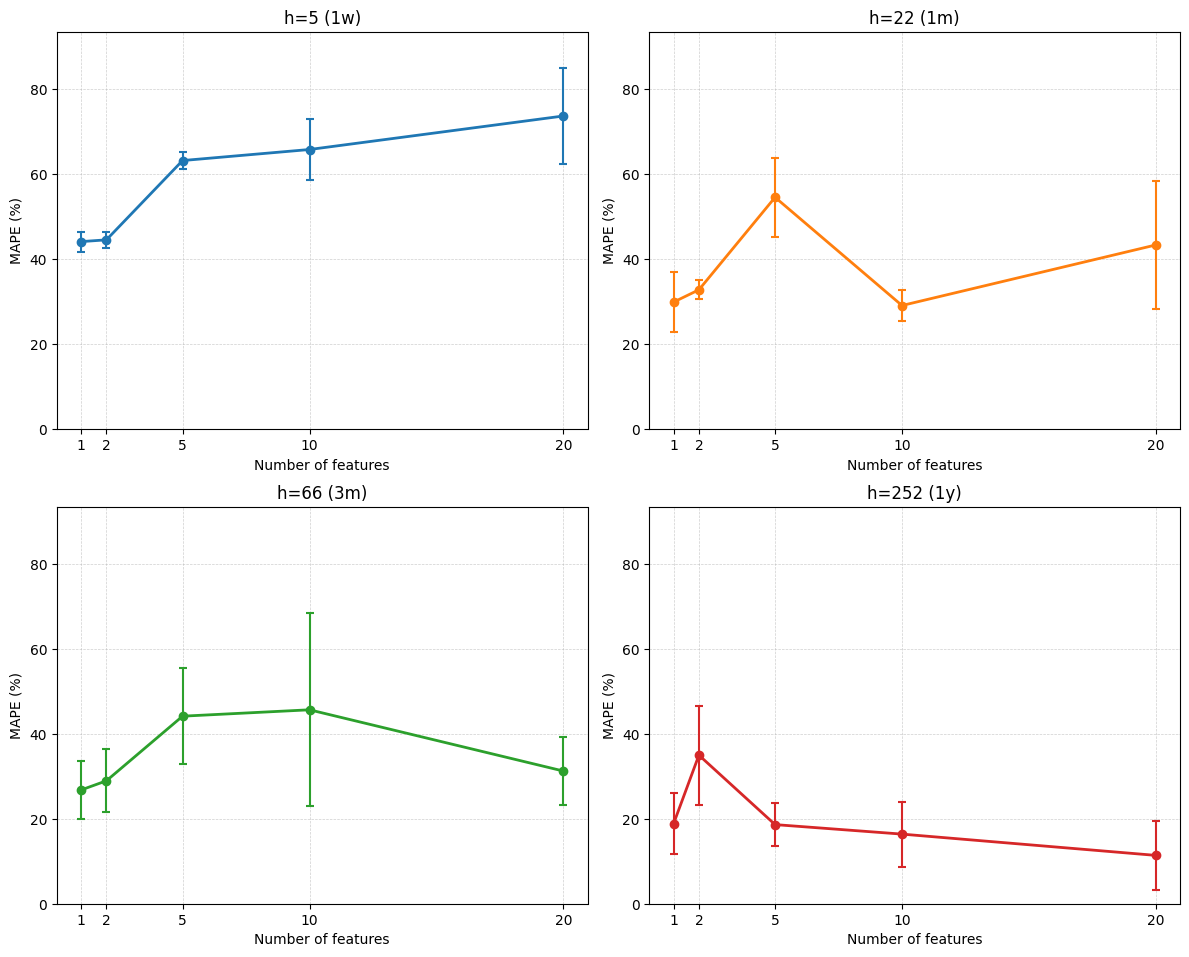

In [15]:
"""
Average MAPE vs. number of features (one plot, four horizons).
- Loads MAPE means/stds from your GRU/LSTM/VMD-LSTM tables
- Maps configs to feature counts
- Aggregates across models per (horizon, features)
- Plots error bars (std across models)
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict

# -----------------------------
# Config: horizons & features
# -----------------------------
HORIZONS = [5, 22, 66, 252]               # trading days
FEATURE_COUNTS = [1, 2, 5, 10, 20]        # x-axis

# Mapping rule from config name to number of features
FEATURE_MAP = {
    "best_vol": 2,
    "best5": 5, "best4_vol": 5,
    "best10": 10, "best9_vol": 10,
    "best20": 20, "best19_vol": 20,
}
DEFAULT_FEATURES = 1  # all other configs

def features_for(config_name: str) -> int:
    return FEATURE_MAP.get(config_name, DEFAULT_FEATURES)

# -----------------------------
# Build dataset
# -----------------------------
rows = []

def add_entry(model_family: str, context: str, config_name: str, stats: dict):
    """
    stats: { horizon(int) : (mape_mean(float), mape_std(float)) }
    Omit horizons that don't exist for a config with '-'.
    """
    for h, (m_mean, m_std) in stats.items():
        if h not in HORIZONS:
            continue
        rows.append({
            "model": model_family,
            "context": context,
            "config": config_name,
            "features": features_for(config_name),
            "horizon": h,
            "mape_mean": float(m_mean),
            "mape_std": float(m_std),
        })

# ---------- GRU, c=5 ----------
add_entry("GRU", "c=5", "abs_log_r",  {5:(41.5,0.6), 22:(22.6,0.9), 66:(17.8,0.6), 252:(12.1,1.3)})
add_entry("GRU", "c=5", "best_vol",   {5:(47.8,3.3), 22:(30.4,2.5), 66:(27.0,0.8), 252:(38.1,11.1)})
add_entry("GRU", "c=5", "best5",      {5:(62.0,0.9), 22:(46.5,3.7), 66:(61.5,25.6), 252:(23.3,0.4)})
add_entry("GRU", "c=5", "best4_vol",  {5:(62.6,3.0), 22:(47.7,2.8), 66:(117.9,30.6), 252:(23.0,4.9)})
add_entry("GRU", "c=5", "best10",     {5:(77.8,7.0), 22:(27.8,3.2), 66:(31.5,5.6), 252:(24.5,0.4)})
add_entry("GRU", "c=5", "best9_vol",  {5:(65.9,7.1), 22:(27.8,5.8), 66:(85.6,5.3), 252:(28.0,4.3)})
add_entry("GRU", "c=5", "best20",     {5:(100.9,11.3), 22:(50.5,21.3), 66:(29.0,5.2), 252:(26.8,0.8)})
add_entry("GRU", "c=5", "best19_vol", {5:(86.5,13.7), 22:(24.4,2.6), 66:(39.5,2.7), 252:(6.5,0.5)})
add_entry("GRU", "c=5", "spx_small",  {22:(39.3,5.1), 66:(30.3,2.1)})
add_entry("GRU", "c=5", "closing_s",  {252:(26.9,2.5)})

# ---------- GRU, c=2h ----------
add_entry("GRU", "c=2h", "abs_log_r",  {5:(44.4,2.5), 22:(24.9,1.2), 66:(27.0,1.5), 252:(24.2,2.6)})
add_entry("GRU", "c=2h", "vol_only",   {5:(45.9,2.2), 22:(29.6,3.5), 66:(30.3,3.5), 252:(28.5,3.4)})
add_entry("GRU", "c=2h", "best_vol",   {5:(43.6,2.3), 22:(36.4,2.6), 66:(41.1,6.1), 252:(25.6,3.1)})
add_entry("GRU", "c=2h", "best5",      {5:(63.1,7.9), 22:(51.1,13.2), 66:(30.6,8.9), 252:(21.5,1.7)})
add_entry("GRU", "c=2h", "best4_vol",  {5:(59.8,6.0), 22:(70.3,27.6), 66:(46.1,30.6), 252:(16.8,4.1)})
add_entry("GRU", "c=2h", "best10",     {5:(75.2,17.8), 22:(32.1,6.9), 66:(30.4,10.8), 252:(8.3,4.3)})
add_entry("GRU", "c=2h", "best9_vol",  {5:(73.0,8.7), 22:(31.3,6.2), 66:(31.9,12.7), 252:(14.7,2.9)})
add_entry("GRU", "c=2h", "best20",     {5:(92.0,17.3), 22:(68.3,13.7), 66:(45.8,12.7), 252:(13.5,3.4)})
add_entry("GRU", "c=2h", "best19_vol", {5:(70.8,6.3), 22:(33.5,9.9), 66:(36.2,5.7), 252:(8.9,3.2)})
add_entry("GRU", "c=2h", "spx_small",  {22:(41.6,4.9), 66:(39.4,3.2)})
add_entry("GRU", "c=2h", "closing_s",  {252:(21.7,5.3)})

# ---------- LSTM, c=5 ----------
add_entry("LSTM", "c=5", "abs_log_r",  {5:(40.4,0.8), 22:(22.1,0.2), 66:(16.7,0.6), 252:(10.7,0.4)})
add_entry("LSTM", "c=5", "vol_only",   {5:(45.9,0.4), 22:(26.9,0.2), 66:(28.6,0.4), 252:(10.4,6.5)})
add_entry("LSTM", "c=5", "best_vol",   {5:(43.7,1.5), 22:(32.6,3.7), 66:(26.7,2.0), 252:(39.0,11.0)})
add_entry("LSTM", "c=5", "best5",      {5:(64.2,7.1), 22:(59.0,16.7), 66:(43.4,10.3), 252:(23.3,0.3)})
add_entry("LSTM", "c=5", "best4_vol",  {5:(66.7,5.7), 22:(48.2,0.9), 66:(106.4,17.7), 252:(17.6,5.3)})
add_entry("LSTM", "c=5", "best10",     {5:(58.6,3.0), 22:(26.6,3.7), 66:(30.6,2.7), 252:(22.1,2.1)})
add_entry("LSTM", "c=5", "best9_vol",  {5:(63.5,12.3), 22:(30.5,6.0), 66:(81.6,0.8), 252:(18.8,2.3)})
add_entry("LSTM", "c=5", "best20",     {5:(112.8,5.9), 22:(46.9,7.4), 66:(22.3,1.2), 252:(20.0,0.7)})
add_entry("LSTM", "c=5", "best19_vol", {5:(68.2,10.9), 22:(41.2,6.0), 66:(28.8,5.5), 252:(3.6,1.4)})
add_entry("LSTM", "c=5", "spx_small",  {22:(37.9,0.7), 66:(29.7,0.9)})
add_entry("LSTM", "c=5", "closing_s",  {252:(26.5,1.2)})

# ---------- LSTM, c=2h ----------
add_entry("LSTM", "c=2h", "abs_log_r",  {5:(43.9,2.7), 22:(24.7,1.3), 66:(22.3,1.8), 252:(13.1,10.0)})
add_entry("LSTM", "c=2h", "vol_only",   {5:(47.0,2.4), 22:(26.9,0.8), 66:(22.8,1.3), 252:(16.4,11.2)})
add_entry("LSTM", "c=2h", "best_vol",   {5:(43.3,1.5), 22:(33.1,3.0), 66:(21.0,3.5), 252:(21.5,9.9)})
add_entry("LSTM", "c=2h", "best5",      {5:(63.7,7.9), 22:(68.4,31.4), 66:(55.6,19.0), 252:(7.4,3.7)})
add_entry("LSTM", "c=2h", "best4_vol",  {5:(64.5,8.9), 22:(90.0,19.7), 66:(37.0,21.2), 252:(13.5,1.0)})
add_entry("LSTM", "c=2h", "best10",     {5:(59.1,11.7), 22:(30.6,4.7), 66:(27.5,14.0), 252:(4.0,1.2)})
add_entry("LSTM", "c=2h", "best9_vol",  {5:(56.9,7.8), 22:(36.0,15.1), 66:(31.0,11.9), 252:(14.1,2.1)})
add_entry("LSTM", "c=2h", "best20",     {5:(86.2,8.8), 22:(64.3,18.4), 66:(21.8,1.7), 252:(2.8,0.8)})
add_entry("LSTM", "c=2h", "best19_vol", {5:(59.3,7.8), 22:(47.4,15.5), 66:(27.7,9.5), 252:(10.0,1.4)})
add_entry("LSTM", "c=2h", "spx_small",  {22:(37.6,3.7), 66:(36.6,4.1)})
add_entry("LSTM", "c=2h", "closing_s",  {252:(12.8,7.3)})

# ---------- VMD-LSTM, c=5h ----------
add_entry("VMD-LSTM", "c=5h", "abs_log_r",  {5:(42.0,3.5), 22:(22.1,0.8), 66:(16.7,0.2), 252:(10.9,1.0)})
add_entry("VMD-LSTM", "c=5h", "vol_only",   {5:(46.1,1.6), 22:(26.5,0.4), 66:(27.0,1.2), 252:(20.9,3.2)})
add_entry("VMD-LSTM", "c=5h", "best_vol",   {5:(44.3,4.1), 22:(31.4,1.4), 66:(28.9,3.3), 252:(50.7,15.1)})
add_entry("VMD-LSTM", "c=5h", "best5",      {5:(65.0,3.0), 22:(53.6,11.1), 66:(34.9,5.9), 252:(19.4,1.1)})
add_entry("VMD-LSTM", "c=5h", "best4_vol",  {5:(60.5,9.0), 22:(46.2,7.7), 66:(108.2,12.5), 252:(20.5,1.9)})
add_entry("VMD-LSTM", "c=5h", "best10",     {5:(63.2,6.0), 22:(24.7,1.8), 66:(42.0,8.2), 252:(19.8,3.8)})
add_entry("VMD-LSTM", "c=5h", "best9_vol",  {5:(64.9,8.1), 22:(23.4,1.7), 66:(64.5,11.3), 252:(9.6,1.4)})
add_entry("VMD-LSTM", "c=5h", "best20",     {5:(82.3,17.8), 22:(26.2,6.4), 66:(24.4,1.0), 252:(18.7,1.7)})
add_entry("VMD-LSTM", "c=5h", "best19_vol", {5:(62.6,8.9), 22:(30.7,9.4), 66:(36.9,7.1), 252:(3.0,1.1)})
add_entry("VMD-LSTM", "c=5h", "spx_small",  {22:(35.5,3.7), 66:(29.7,4.3)})
add_entry("VMD-LSTM", "c=5h", "closing_s",  {252:(28.1,0.6)})

df = pd.DataFrame(rows)

# -----------------------------
# Remove outliers using IQR method
# -----------------------------
def remove_outliers_iqr(data, column='mape_mean'):
    """Remove outliers using IQR method"""
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Filter out outliers
    filtered_data = data[(data[column] >= lower_bound) & (data[column] <= upper_bound)]
    
    print(f"Outliers removed: {len(data) - len(filtered_data)} out of {len(data)} entries")
    print(f"IQR bounds: [{lower_bound:.2f}, {upper_bound:.2f}]")
    
    return filtered_data

# Remove outliers from the dataset
df_clean = remove_outliers_iqr(df, 'mape_mean')

# -----------------------------
# Aggregate across models (using cleaned data)
# -----------------------------
agg = (df_clean.groupby(["horizon", "features"])["mape_mean"]
         .agg(["mean", "std"])
         .reset_index()
         .sort_values(["horizon", "features"]))

def values_for(h, col):
    sub = agg[agg["horizon"] == h].set_index("features")
    return [float(sub[col].get(k, np.nan)) for k in FEATURE_COUNTS]

y_means = {h: values_for(h, "mean") for h in HORIZONS}
y_stds  = {h: values_for(h, "std")  for h in HORIZONS}

# -----------------------------
# Plot (4 subplots, 1 for each horizon) with I-shaped error bars
# -----------------------------
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()  # Flatten for easier indexing

# Horizon labels and colors for consistency
horizon_labels = {5: '1w', 22: '1m', 66: '3m', 252: '1y'}
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

# Calculate global y-axis limit for consistent scaling
max_ylim = 0
for h in HORIZONS:
    if not all(np.isnan(y_means[h])) and not all(np.isnan(y_stds[h])):
        max_mean = np.nanmax(y_means[h])
        max_std = np.nanmax(y_stds[h])
        max_ylim = max(max_ylim, max_mean + max_std)

max_ylim = max_ylim * 1.1 if max_ylim > 0 else 100

for idx, h in enumerate(HORIZONS):
    ax = axes[idx]
    
    # Plot error bars for this horizon
    ax.errorbar(FEATURE_COUNTS, y_means[h], yerr=y_stds[h], marker='o', 
               capsize=3, capthick=1.5, elinewidth=1.5, 
               color=colors[idx], markersize=6, linewidth=2)
    
    # Customize subplot
    ax.set_xlabel('Number of features')
    ax.set_ylabel('MAPE (%)')
    ax.set_title(f'h={h} ({horizon_labels[h]})')
    
    # Set x-axis ticks to only show specific values
    ax.set_xticks([1, 2, 5, 10, 20])
    
    # Set consistent y-axis limits for better comparison
    ax.set_ylim(0, max_ylim)
    
    # Grid: integer values on x-axis only
    ax.grid(True, which='major', axis='x', linestyle='--', linewidth=0.5, alpha=0.6)
    ax.grid(True, which='major', axis='y', linestyle='--', linewidth=0.5, alpha=0.6)

# Add overall figure title
# fig.suptitle('h=5 (1w), h=22 (1m), h=66 (3m), h=252 (1y)', fontsize=14, y=0.98)

plt.tight_layout()
plt.subplots_adjust(top=0.93)  # Make room for title

plt.savefig('avg_mape_by_features_clean.png', dpi=200, bbox_inches='tight')
print("Saved figure to avg_mape_by_features_clean.png")
